In [7]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load weighted-degree vectors for healthy (non-OAS) and unhealthy (OAS) subjects
# Group membership is inferred from the subject ID itself: OAS subjects are unhealthy,
# everything else under wasserstein_graphs_inv1pW is healthy.

def load_weighted_degree(subject_dir):
    order = (os.path.join(subject_dir, "parcel_order.txt"))
    with open(order, encoding="utf-8") as f:
        n_parcels = sum(1 for _ in f)
    degree = np.memmap(
        os.path.join(subject_dir, "weighted_degree.dat"),
        dtype="float64", mode="r", shape=(n_parcels,),
    )
    return np.array(degree)


healthy_degree_vectors = []
unhealthy_degree_vectors = []
healthy_ids = []
unhealthy_ids = []

for subject_dir in sorted(glob("../outputs/wasserstein_graphs_inv1pW/*")):
    subject_id = os.path.basename(subject_dir)
    degree_vector = load_weighted_degree(subject_dir)

    if "OAS" in subject_id:
        unhealthy_degree_vectors.append(degree_vector)
        unhealthy_ids.append(subject_id)
    else:
        healthy_degree_vectors.append(degree_vector)
        healthy_ids.append(subject_id)

print(f"Healthy subjects   ({len(healthy_ids)}): {healthy_ids}")
print(f"Unhealthy subjects ({len(unhealthy_ids)}): {unhealthy_ids}")


Healthy subjects   (20): ['sub-0001', 'sub-0002', 'sub-0003', 'sub-0004', 'sub-0005', 'sub-0006', 'sub-0008', 'sub-0009', 'sub-0010', 'sub-0011', 'sub-0014', 'sub-0015', 'sub-0017', 'sub-0018', 'sub-0020', 'sub-0021', 'sub-0026', 'sub-0030', 'sub-0032', 'sub-0033']
Unhealthy subjects (20): ['sub-OAS30007', 'sub-OAS30012', 'sub-OAS30013', 'sub-OAS30016', 'sub-OAS30019', 'sub-OAS30022', 'sub-OAS30024', 'sub-OAS30025', 'sub-OAS30027', 'sub-OAS30028', 'sub-OAS30029', 'sub-OAS30031', 'sub-OAS30035', 'sub-OAS30038', 'sub-OAS30040', 'sub-OAS30041', 'sub-OAS30043', 'sub-OAS30051', 'sub-OAS30052', 'sub-OAS30056']


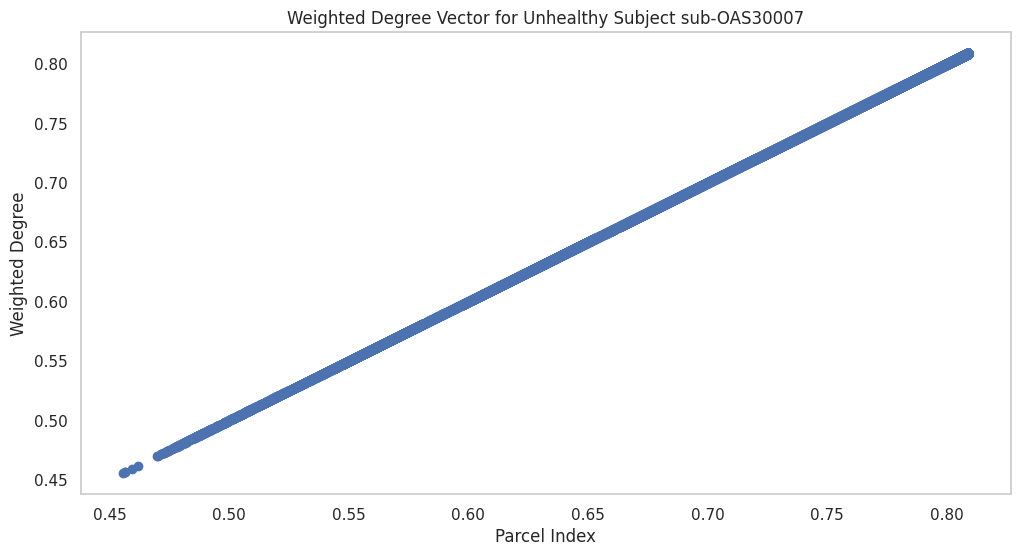

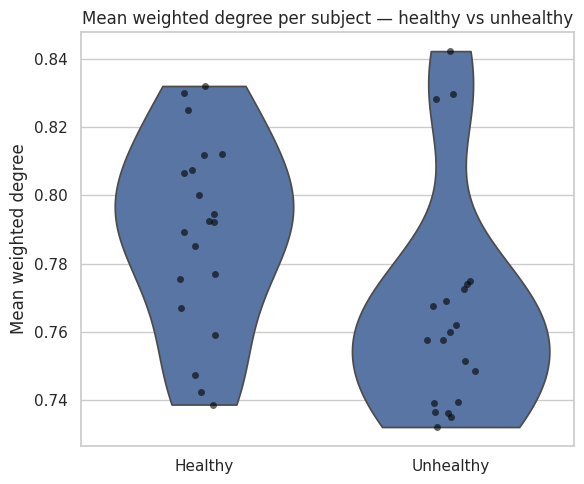

,subject_id,mean_weighted_degree,group
0,sub-0001,0.800083,Healthy
1,sub-0002,0.829982,Healthy
2,sub-0003,0.789407,Healthy
3,sub-0004,0.806699,Healthy
4,sub-0005,0.824926,Healthy
5,sub-0006,0.807395,Healthy
6,sub-0008,0.776926,Healthy
7,sub-0009,0.792128,Healthy
8,sub-0010,0.767032,Healthy
9,sub-0011,0.738707,Healthy


In [9]:
# Visualise healthy vs unhealthy: per-subject mean weighted degree

plot_df = pd.DataFrame({
    "subject_id": healthy_ids + unhealthy_ids,
    "mean_weighted_degree": (
        [v.mean() for v in healthy_degree_vectors]
        + [v.mean() for v in unhealthy_degree_vectors]
    ),
    "group": ["Healthy"] * len(healthy_ids) + ["Unhealthy"] * len(unhealthy_ids),
})

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=plot_df, x="group", y="mean_weighted_degree", inner=None, ax=ax, cut=0)
sns.stripplot(data=plot_df, x="group", y="mean_weighted_degree", color="black", alpha=0.6, ax=ax)
ax.set_title("Mean weighted degree per subject — healthy vs unhealthy")
ax.set_xlabel("")
ax.set_ylabel("Mean weighted degree")
fig.tight_layout()
plt.show()

plot_df


In [ ]:
def align_to_common(
    subjects: list[tuple[str, list[str], np.ndarray]]
) -> tuple[list[str], dict[str, np.ndarray]]:
    """Return (common_parcel_ids, {sub_id: aligned_degree_array})."""
    common = set(subjects[0][1])
    for _, order, _ in subjects[1:]:
        common &= set(order)
    common_ids = sorted(common)

    aligned: dict[str, np.ndarray] = {}

    # Align each subject's degree vector to the common parcel order
    for sub_id, order, degree in subjects:

        # Create a mapping from parcel ID to its index in the subject's order
        pos = {pid: i for i, pid in enumerate(order)}

        # Create an index array that maps the common parcel IDs to their corresponding indices in the subject's order
        idx = np.array([pos[pid] for pid in common_ids], dtype=np.int64)

        # Use the index array to align the subject's degree vector to the common parcel order
        aligned[sub_id] = degree[idx]

    return common_ids, aligned